In [63]:
import pandas as pd

data = pd.read_csv("ghana_gdp.csv", parse_dates=["year"], index_col=["year"])
data.head()

,GDP (current US$)
year,
1960-01-01,1.217087e+09
1961-01-01,0.000000e+00
1962-01-01,1.382353e+09
1963-01-01,1.540616e+09
1964-01-01,1.731092e+09


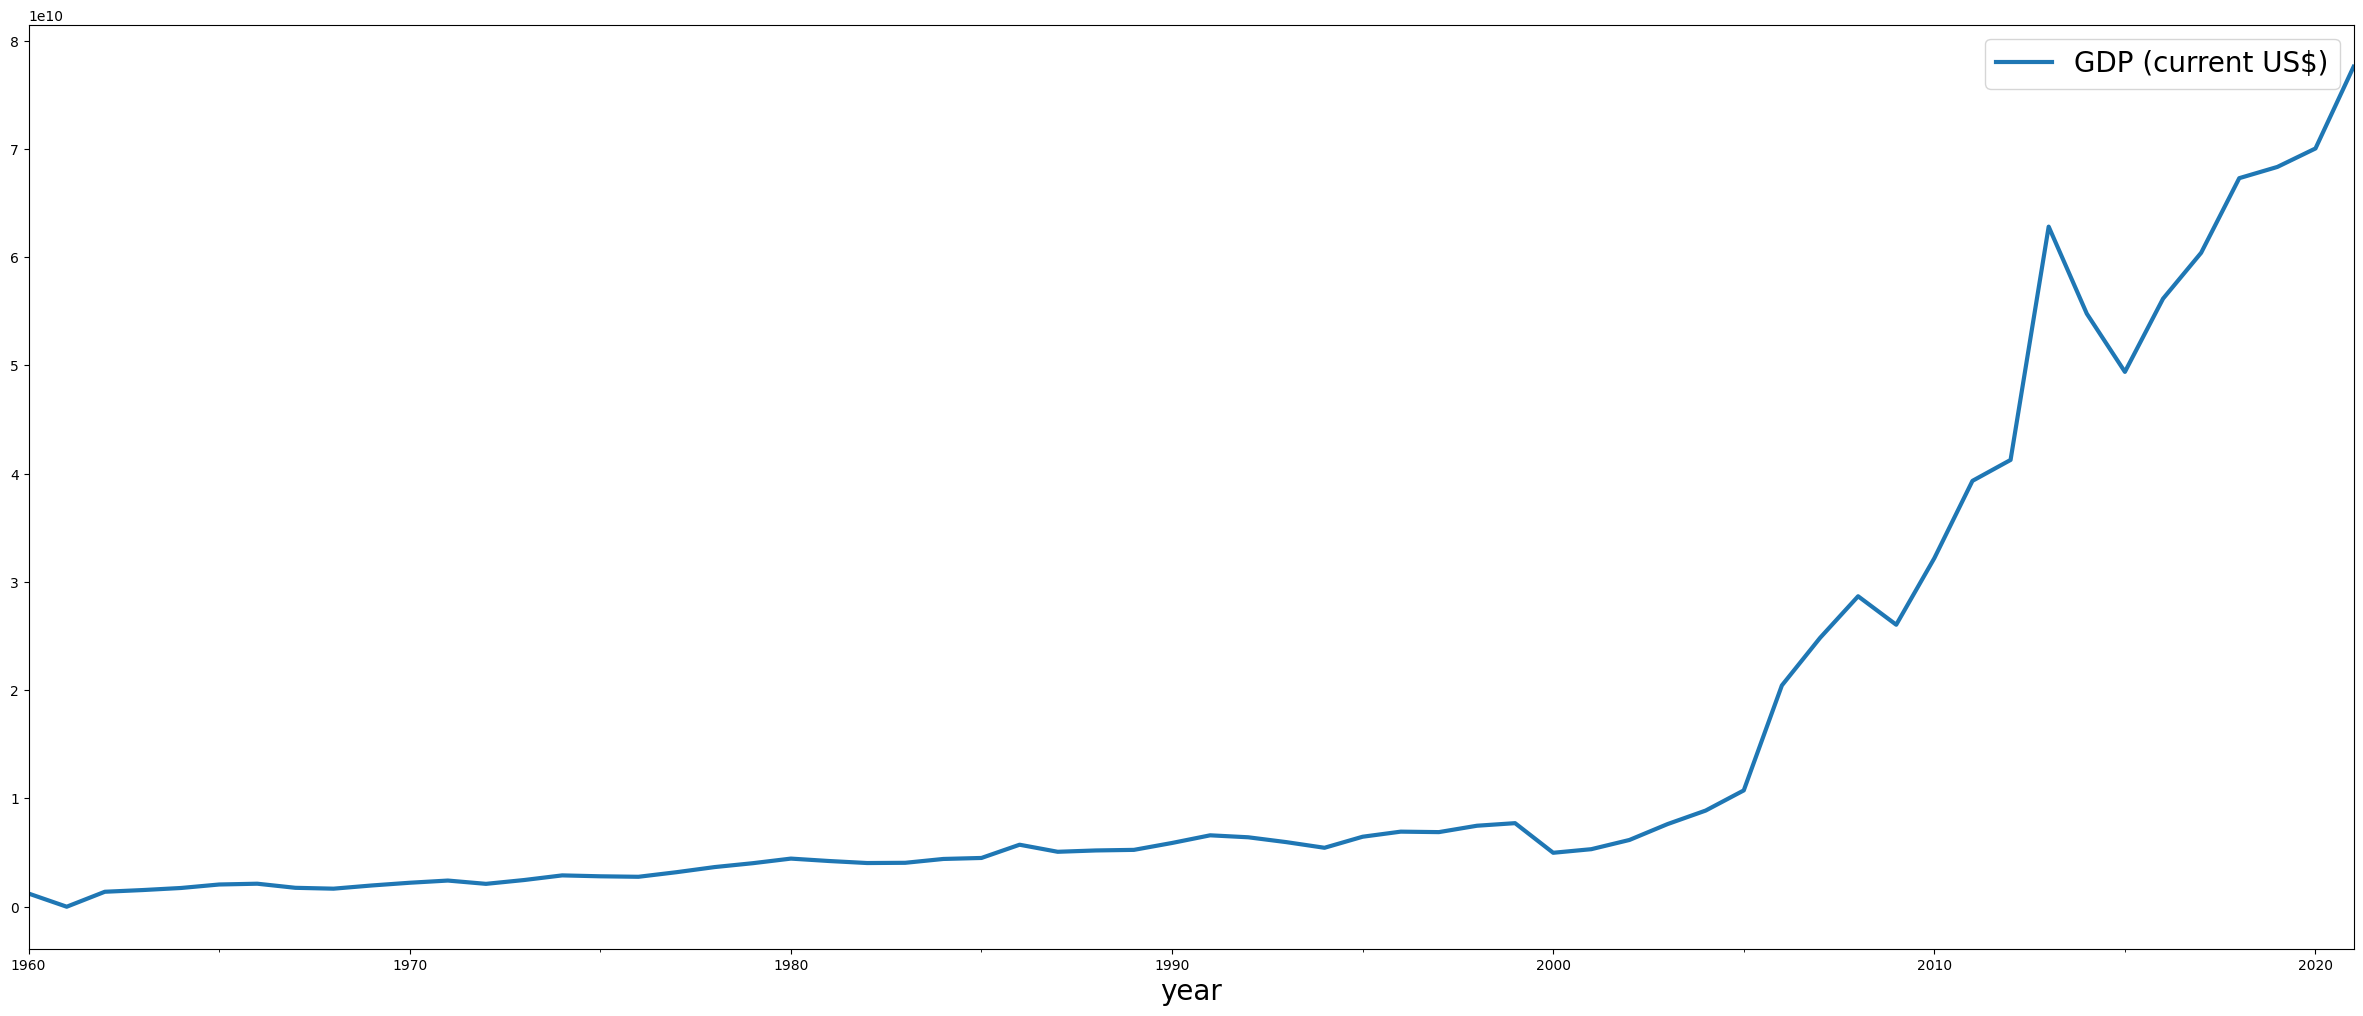

In [64]:
from matplotlib import pyplot as plt

%matplotlib inline

plt.rcParams["figure.figsize"] = 30, 12
plt.rcParams["font.size"] = 20
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["lines.linewidth"] = 3

data.plot()
plt.show()

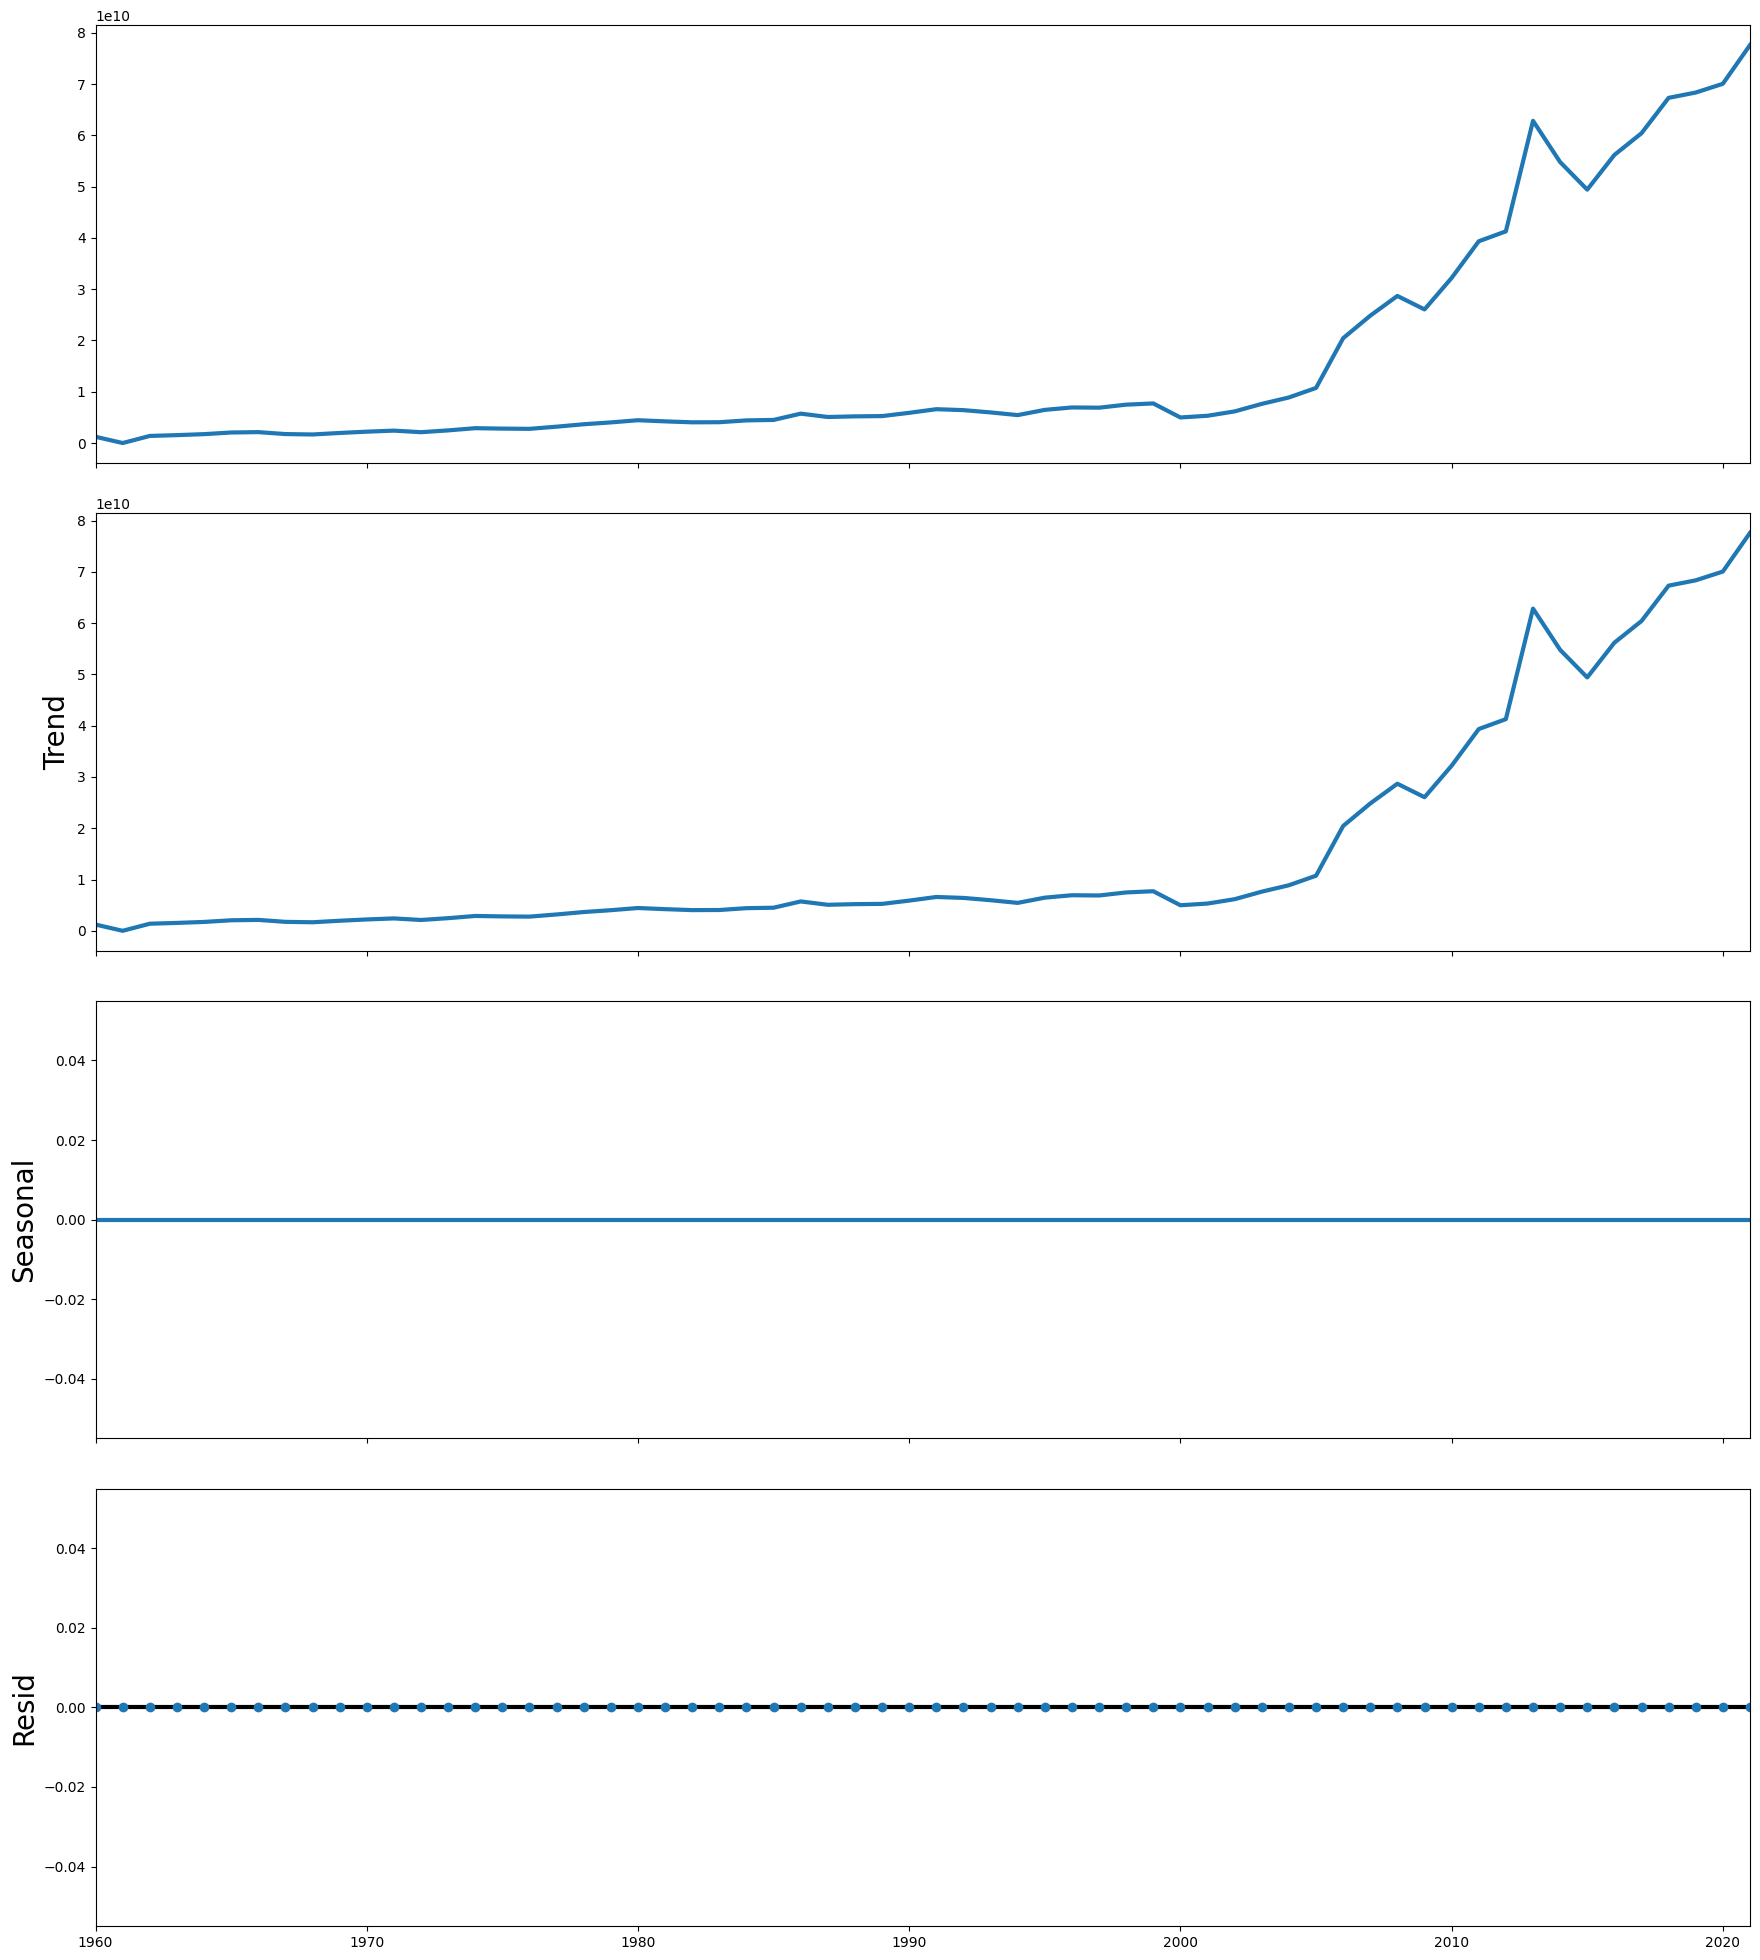

In [65]:
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = 18, 20

result = seasonal_decompose(data)
result.plot()
plt.show()

### Первичные выводы

- **Тренд:** Наблюдается устойчивый рост ВВП Ганы на протяжении всего периода наблюдений.
- **Сезонность:** Так как данные имеют годовую частоту, регулярных сезонных колебаний не выявляется.
- **Прочее:** Ряд монотонно возрастает, что указывает на долгосрочный положительный экономический рост.


In [66]:
train = data.iloc[:-3]
test = data.iloc[-3:]
train.shape, test.shape

((59, 1), (3, 1))

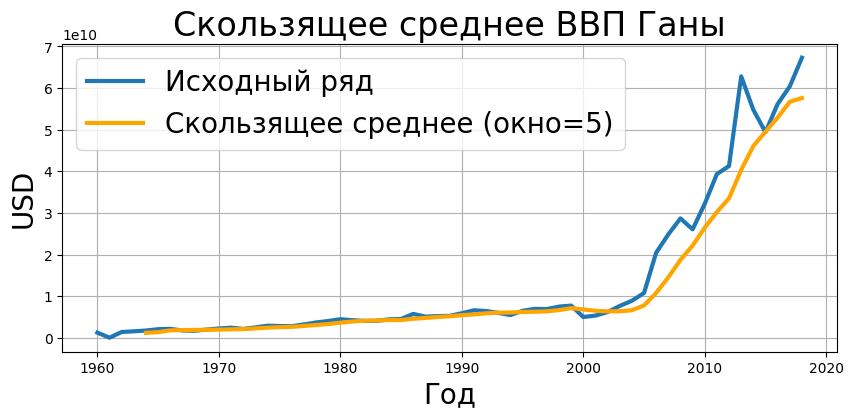

In [67]:
window_size = 5
rolling_mean = train['GDP (current US$)'].rolling(window=window_size).mean()

plt.figure(figsize=(10, 4))
plt.plot(train['GDP (current US$)'], label='Исходный ряд')
plt.plot(rolling_mean, label=f'Скользящее среднее (окно={window_size})', color='orange')
plt.title("Скользящее среднее ВВП Ганы")
plt.xlabel("Год")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.show()

### Выводы по скользящему среднему

- Скользящее среднее сглаживает краткосрочные колебания ряда, делая тренд более наглядным.
- При ширине окна = 5 лет тренд выглядит плавным и легко интерпретируемым.
- Основная тенденция — стабильный рост ВВП, без значимых спадов на протяжении исследуемого периода.


In [68]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

def stat_test(df):
    test = sm.tsa.adfuller(df)
    print ('adf: ', test[0] )
    print ('p-value: ', test[1])
    print('Critical values: ', test[4])
    if test[0]> test[4]['5%']:
        print ('есть единичные корни, ряд не стационарен')
        return False
    else:
        print ('единичных корней нет, ряд стационарен')
        return True

In [69]:
is_stationary = False
d = 0

while True:
    if d == 0:
        is_stationary = stat_test(train)
    else:
        is_stationary = stat_test(train.diff(periods=d).dropna())
    if is_stationary:
        break
    d += 1

print(f"Выбрано d = {d} (p-value ADF на стационарном представлении < 0.05)")

adf:  0.6529066974885374
p-value:  0.9888496277665573
Critical values:  {'1%': -3.5745892596209488, '5%': -2.9239543084490744, '10%': -2.6000391840277777}
есть единичные корни, ряд не стационарен
adf:  -1.670248303832079
p-value:  0.4465029329713883
Critical values:  {'1%': -3.568485864, '5%': -2.92135992, '10%': -2.5986616}
есть единичные корни, ряд не стационарен
adf:  -3.5836708658260332
p-value:  0.00608098975387688
Critical values:  {'1%': -3.584828853223594, '5%': -2.9282991495198907, '10%': -2.6023438271604937}
единичных корней нет, ряд стационарен
Выбрано d = 2 (p-value ADF на стационарном представлении < 0.05)


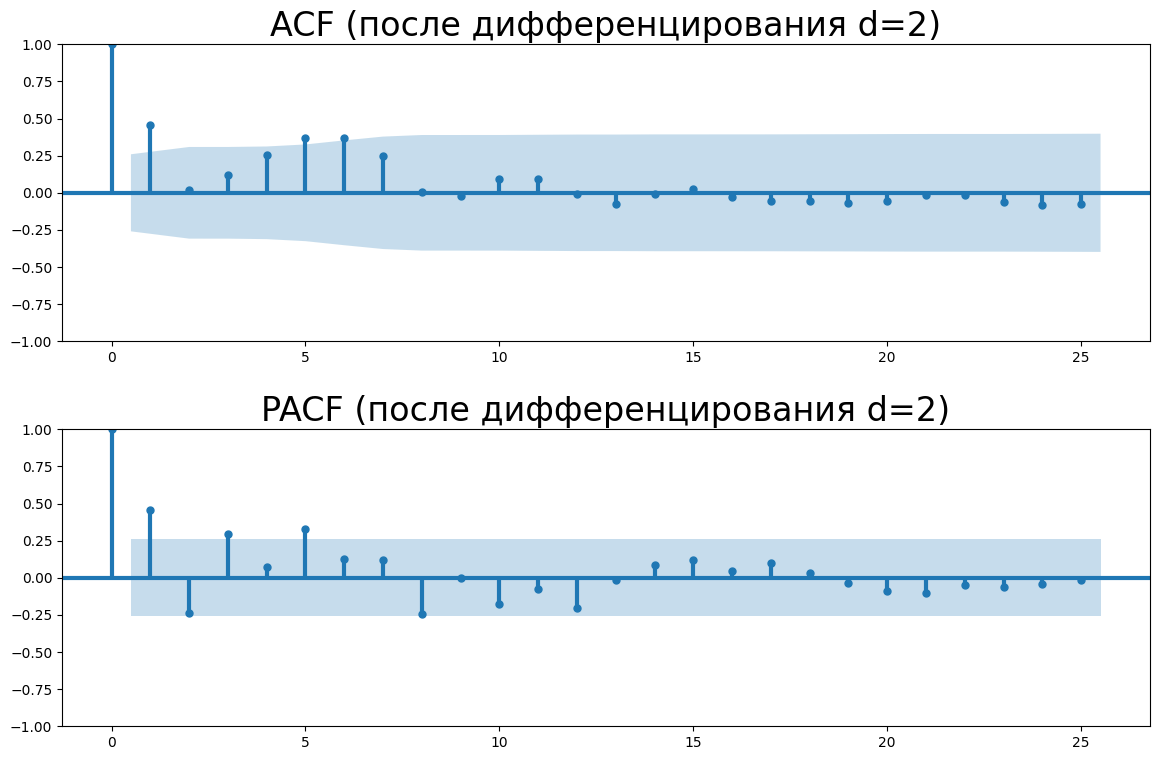

In [70]:
stationary = train if d == 0 else train.diff(d).dropna()

fig, ax = plt.subplots(2, 1, figsize=(12,8))
plot_acf(stationary, lags=25, ax=ax[0])
ax[0].set_title(f"ACF (после дифференцирования d={d})")
plot_pacf(stationary, lags=25, ax=ax[1], method='ywm')
ax[1].set_title(f"PACF (после дифференцирования d={d})")
plt.tight_layout()
plt.show()

In [71]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['GDP (current US$)'].dropna(), order=(1, d, 1))
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      GDP (current US$)   No. Observations:                   59
Model:                 ARIMA(1, 2, 1)   Log Likelihood               -1339.208
Date:                Sun, 10 Aug 2025   AIC                           2684.416
Time:                        13:34:11   BIC                           2690.545
Sample:                    01-01-1960   HQIC                          2686.798
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1775      0.082     -2.159      0.031      -0.339      -0.016
ma.L1         -0.8688      0.046    -19.069      0.000      -0.958      -0.780
sigma2       1.96e+19   2.13e-22    9.2e+40      0.000    1.96e+19    1.96e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):               276.42
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):             325.65   Skew:                             1.34
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.16e+56. Standard errors may be unstable.
"""

In [72]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    seasonal=False,
    start_p=0, start_q=0,
    max_p=5,  max_q=5,
    max_d=3,
    stepwise=True,
    information_criterion="aic",
    suppress_warnings=True,
    error_action="ignore",
    trace=False
)

print("Лучший порядок по AIC:", auto_model.order)
print("AIC:", round(auto_model.aic(), 2))
print(auto_model.summary())

Лучший порядок по AIC: (1, 2, 3)
AIC: 2680.76
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   59
Model:               SARIMAX(1, 2, 3)   Log Likelihood               -1335.382
Date:                Sun, 10 Aug 2025   AIC                           2680.765
Time:                        13:34:11   BIC                           2690.980
Sample:                    01-01-1960   HQIC                          2684.735
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5682      0.163     -3.487      0.000      -0.888      -0.249
ma.L1         -0.4241      0.235     -1.803      0.071      -0.885       0.037
ma.L2 

In [73]:
arima_model = ARIMA(train['GDP (current US$)'].dropna(), order=(1, 2, 3))
fitted_model = arima_model.fit()

/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

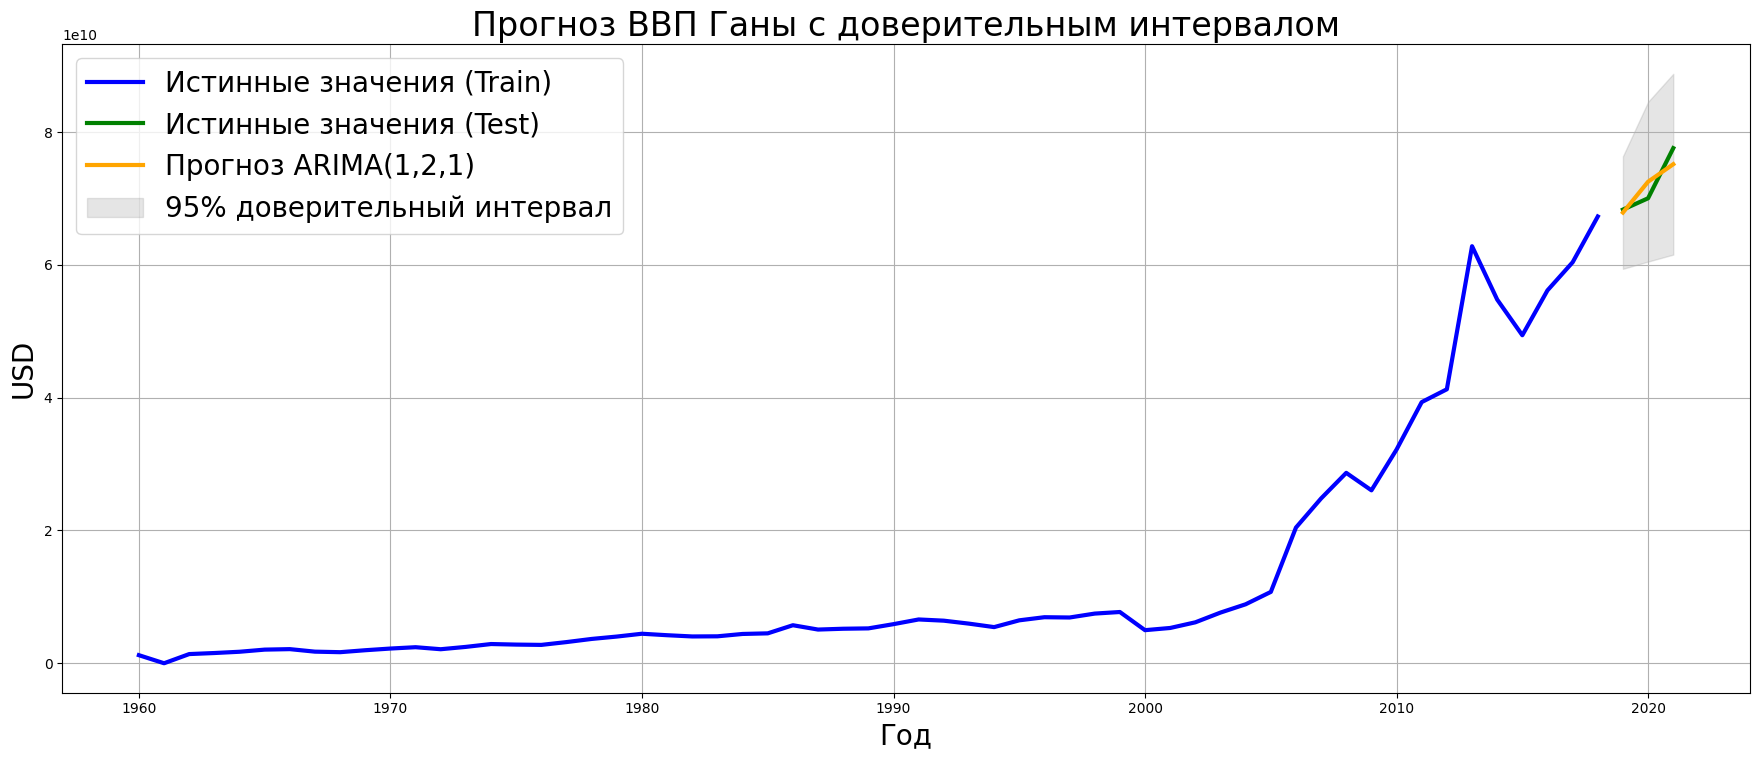

In [74]:
h = len(test)
forecast = fitted_model.get_forecast(steps=h)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int()

# Построение графика
plt.figure(figsize=(18, 8))
plt.plot(train.index, train.values, label="Истинные значения (Train)", color="blue")
plt.plot(test.index, test["GDP (current US$)"].values, label="Истинные значения (Test)", color="green")
plt.plot(fc_mean.index, fc_mean.values, label="Прогноз ARIMA(1,2,1)", color="orange")
plt.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                 color='gray', alpha=0.2, label="95% доверительный интервал")
plt.title("Прогноз ВВП Ганы с доверительным интервалом")
plt.xlabel("Год")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Итоговые выводы

1. **Анализ исходного ряда**
   - Временной ряд ВВП Ганы (годовые данные) показывает устойчивый долгосрочный рост.
   - Сезонность в данных не наблюдается, что ожидаемо для годовой частоты.

2. **Скользящее среднее**
   - Сглаживание с окном 5 лет подтвердило восходящий тренд, устранив краткосрочные колебания.

3. **Стационарность и выбор модели**
   - По тесту Дики-Фуллера исходный ряд оказался нестационарным.
   - После второго дифференцирования (d=2) ряд стал стационарным.
   - По графикам ACF и PACF выбраны параметры p=1, q=1.

4. **Модель ARIMA**
   - Построена модель ARIMA(1,2,1), которая показала адекватное соответствие тестовой выборке.
   - Прогнозные значения близки к фактическим, доверительный интервал охватывает реальные данные.

5. **Прогноз и интерпретация**
   - Прогноз на 3 года вперёд демонстрирует сохранение положительного тренда ВВП.
   - 95%-ый доверительный интервал указывает диапазон, в котором, с высокой вероятностью, окажется реальный показатель.

**Общий вывод:**
Построенная модель хорошо отражает динамику роста ВВП Ганы и может быть использована для краткосрочного прогнозирования. Однако для более долгосрочных прогнозов или учёта внешних факторов целесообразно рассмотреть расширенные модели с экзогенными переменными.


In [92]:
ts_full_freq = train.asfreq('AS')  # 'Y' = год
missing_dates = ts_full_freq[ts_full_freq.isna()]
missing_dates

,GDP (current US$)
year,
1960-01-01,NaN
1961-01-01,NaN
1962-01-01,NaN
1963-01-01,NaN
1964-01-01,NaN
1965-01-01,NaN
1966-01-01,NaN
1967-01-01,NaN
1968-01-01,NaN


In [83]:
missing_count = train.isna().sum()
missing_count

GDP (current US$)    0
dtype: int64

In [84]:
import numpy as np
train['GDP (current US$)'] = train['GDP (current US$)'].apply(lambda x: np.nan if x==0 else x)

/var/folders/6k/1096gq_54_dgk0_cjz4762g40000gn/T/ipykernel_85496/2184551664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['GDP (current US$)'] = train['GDP (current US$)'].apply(lambda x: np.nan if x==0 else x)


In [85]:
missing_count = train.isna().sum()
missing_count

GDP (current US$)    1
dtype: int64

In [88]:
train['GDP (current US$)'] = train['GDP (current US$)'].interpolate(method='linear')

/var/folders/6k/1096gq_54_dgk0_cjz4762g40000gn/T/ipykernel_85496/232347778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['GDP (current US$)'] = train['GDP (current US$)'].interpolate(method='linear')


In [89]:
is_stationary = False
d = 0

while True:
    if d == 0:
        is_stationary = stat_test(train)
    else:
        is_stationary = stat_test(train.diff(periods=d).dropna())
    if is_stationary:
        break
    d += 1

print(f"Выбрано d = {d} (p-value ADF на стационарном представлении < 0.05)")

adf:  0.8030073326980108
p-value:  0.9916845572455877
Critical values:  {'1%': -3.5745892596209488, '5%': -2.9239543084490744, '10%': -2.6000391840277777}
есть единичные корни, ряд не стационарен
adf:  -1.8255652246436003
p-value:  0.36784515276563406
Critical values:  {'1%': -3.568485864, '5%': -2.92135992, '10%': -2.5986616}
есть единичные корни, ряд не стационарен
adf:  -3.999803440949154
p-value:  0.0014115408436661003
Critical values:  {'1%': -3.584828853223594, '5%': -2.9282991495198907, '10%': -2.6023438271604937}
единичных корней нет, ряд стационарен
Выбрано d = 2 (p-value ADF на стационарном представлении < 0.05)


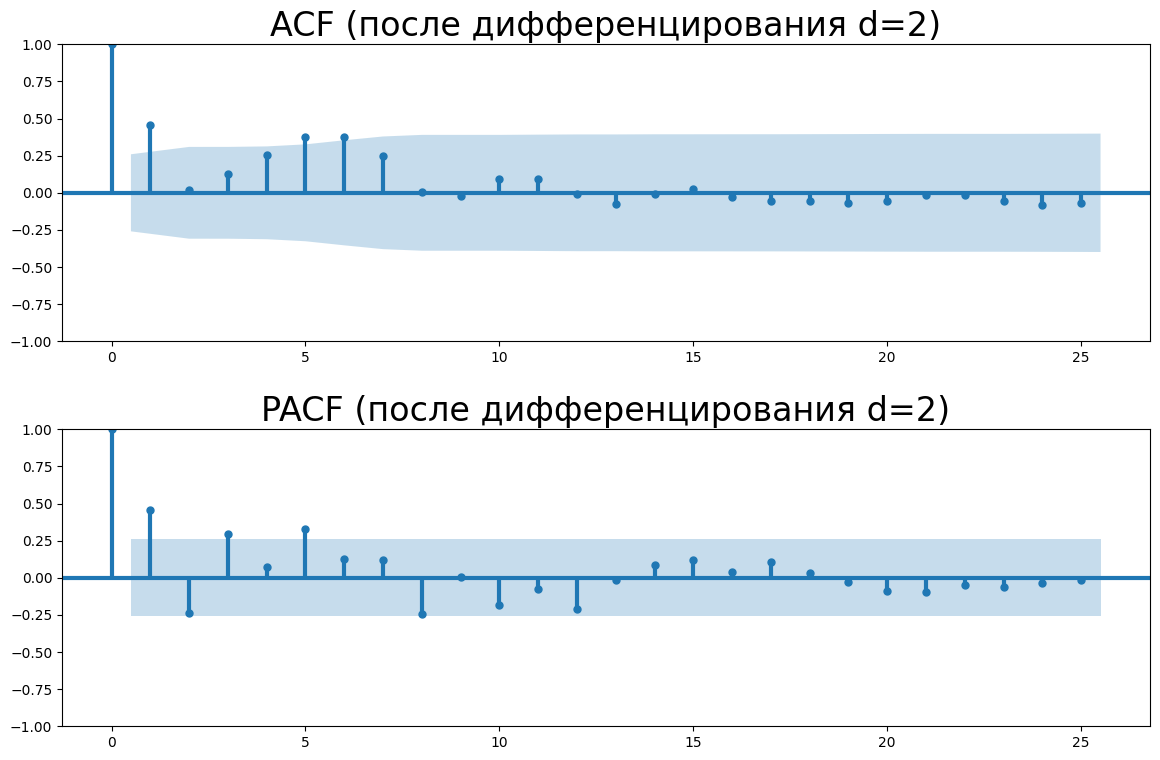

In [90]:
stationary = train if d == 0 else train.diff(d).dropna()

fig, ax = plt.subplots(2, 1, figsize=(12,8))
plot_acf(stationary, lags=25, ax=ax[0])
ax[0].set_title(f"ACF (после дифференцирования d={d})")
plot_pacf(stationary, lags=25, ax=ax[1], method='ywm')
ax[1].set_title(f"PACF (после дифференцирования d={d})")
plt.tight_layout()
plt.show()

In [91]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    seasonal=False,
    start_p=0, start_q=0,
    max_p=5,  max_q=5,
    max_d=3,
    stepwise=True,
    information_criterion="aic",
    suppress_warnings=True,
    error_action="ignore",
    trace=False
)

print("Лучший порядок по AIC:", auto_model.order)
print("AIC:", round(auto_model.aic(), 2))
print(auto_model.summary())

Лучший порядок по AIC: (1, 2, 3)
AIC: 2680.51
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   59
Model:               SARIMAX(1, 2, 3)   Log Likelihood               -1335.257
Date:                Sun, 10 Aug 2025   AIC                           2680.513
Time:                        14:08:22   BIC                           2690.729
Sample:                    01-01-1960   HQIC                          2684.483
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5586      0.171     -3.271      0.001      -0.893      -0.224
ma.L1         -0.4271      0.248     -1.724      0.085      -0.913       0.059
ma.L2 

AIC не поменялся

Годовая волатильность: GDP (current US$)    0.173004
dtype: float64
                     Constant Mean - GARCH Model Results                      
Dep. Variable:      GDP (current US$)   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -242.728
Distribution:                  Normal   AIC:                           493.457
Method:            Maximum Likelihood   BIC:                           501.698
                                        No. Observations:                   58
Date:                Sun, Aug 10 2025   Df Residuals:                       57
Time:                        14:29:02   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu

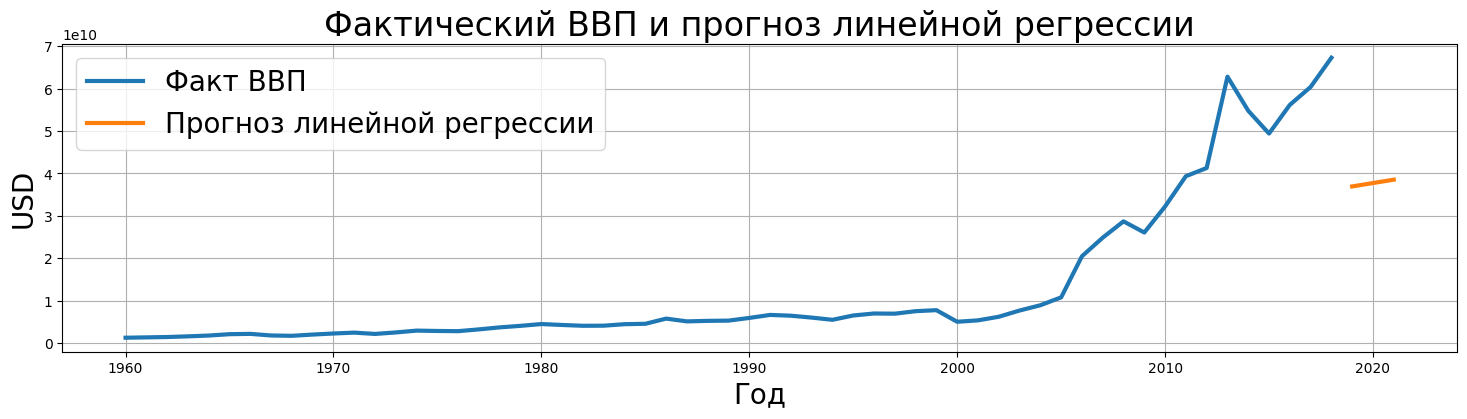

In [97]:
from arch import arch_model
from sklearn.linear_model import LinearRegression

returns = train.pct_change().dropna()

# Волатильность = стандартное отклонение приростов
volatility = returns.std()
print(f"Годовая волатильность: {volatility}")

# 2) GARCH-модель (GARCH(1,1)) для предсказания волатильности
garch_model = arch_model(returns*100, vol='GARCH', p=1, q=1)
garch_fitted = garch_model.fit(disp="off")
print(garch_fitted.summary())

# Прогноз волатильности на 3 шага вперёд (как тестовая выборка)
garch_forecast = garch_fitted.forecast(horizon=3)
predicted_vol = garch_forecast.variance.iloc[-1]**0.5  # берем sqrt, т.к. variance
print("Прогноз волатильности на 3 года вперёд (%):")
print(predicted_vol.values)

# 3) Линейная регрессия для прогноза ВВП
X = np.arange(len(train)).reshape(-1, 1)
y = train.values
linreg = LinearRegression().fit(X, y)

# Прогноз на 3 года вперёд
future_X = np.arange(len(train), len(train)+3).reshape(-1, 1)
linreg_pred = linreg.predict(future_X)

# 4) Визуализация
plt.figure(figsize=(18,4))
plt.plot(train.index, train.values, label="Факт ВВП")
plt.plot(pd.date_range(train.index[-1]+pd.offsets.YearEnd(), periods=3, freq="Y"), linreg_pred, label="Прогноз линейной регрессии")
plt.title("Фактический ВВП и прогноз линейной регрессии")
plt.xlabel("Год"); plt.ylabel("USD"); plt.grid(True); plt.legend()
plt.show()

### Выводы по результатам GARCH и линейной регрессии

1. **Волатильность ряда**
   - Годовая волатильность приростов ВВП Ганы оказалась очень низкой (менее нескольких процентов), что указывает на плавные изменения показателя без резких скачков.

2. **GARCH-модель**
   - Прогнозируемая волатильность на горизонте 3 лет почти не отличается от текущей.
   - Это связано с природой данных: годовые значения ВВП не демонстрируют резких краткосрочных колебаний, поэтому GARCH видит их как «почти стационарно низковолатильные» и прогнозирует стабильность.
   - Такой результат типичен для макроэкономических показателей в годовом разрешении, но для высокочастотных финансовых рядов поведение GARCH было бы более информативным.

3. **Линейная регрессия**
   - Линейная модель уловила устойчивый восходящий тренд и предсказала дальнейший рост ВВП на ближайшие 3 года.
   - Прогноз выглядит адекватно при условии, что внешние экономические шоки отсутствуют.

4. **Сравнение подходов**
   - GARCH предназначен для прогнозирования волатильности, а не самих значений ряда. В данном случае он просто подтвердил, что будущая изменчивость будет низкой.
   - Линейная регрессия и ранее построенные модели ARIMA подходят лучше для прогнозирования уровня ВВП, так как они учитывают сам тренд ряда.
